In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from IPython.display import display

%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 125,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})
print("Imports ready. Every model below starts with w = 0 and b = 0.")

Imports ready. Every model below starts with w = 0 and b = 0.


## Task 1 — Predict house price from area

The large area values made the original slope and intercept updates poorly
balanced. Standardizing area lets both parameters learn efficiently with
`alpha = 0.1`. The mean and standard deviation are saved so the learned
equation can be converted back to ordinary area units.

In [2]:
area = [2600, 3000, 3200, 3600, 4000, 4100]
price = [550000, 565000, 610000, 595000, 760000, 810000]

x_original = np.array(area, dtype=float)
y = np.array(price, dtype=float)
m = len(x_original)

x_mean = x_original.mean()
x_std = x_original.std()
x = (x_original - x_mean) / x_std

print(f"Mean area: {x_mean:,.6f}")
print(f"Area standard deviation: {x_std:,.6f}")
display(pd.DataFrame({
    "Area": x_original,
    "Standardized area": x,
    "Actual price": y,
}).round(6))

Mean area: 3,416.666667
Area standard deviation: 536.708073


,Area,Standardized area,Actual price
0,2600.0,-1.521622,550000.0
1,3000.0,-0.776338,565000.0
2,3200.0,-0.403696,610000.0
3,3600.0,0.341589,595000.0
4,4000.0,1.086873,760000.0
5,4100.0,1.273194,810000.0


In [3]:
# Fresh parameters for the standardized input.
w_scaled = 0.0
b_scaled = 0.0
alpha = 0.1
epochs = 500

cost_history = [float(np.mean((w_scaled * x + b_scaled - y) ** 2) / 2)]

for i in range(epochs):
    total_wxbyx = 0.0
    total_wxby = 0.0

    for j in range(m):
        error = w_scaled * x[j] + b_scaled - y[j]
        total_wxbyx += error * x[j]
        total_wxby += error

    # Both gradients use the same old parameters.
    temp_w = w_scaled - alpha * total_wxbyx / m
    temp_b = b_scaled - alpha * total_wxby / m
    w_scaled = temp_w
    b_scaled = temp_b

    # Report the cost AFTER this epoch's update.
    jwb = float(np.mean((w_scaled * x + b_scaled - y) ** 2) / 2)
    if not np.isfinite(jwb):
        raise FloatingPointError("Training diverged; check the input scaling.")
    cost_history.append(jwb)

    if i == 0 or (i + 1) % 100 == 0:
        print(f"Epoch {i + 1:3d} | Cost = {jwb:,.12f}")

# Convert the learned equation to ORIGINAL input units.
w = w_scaled / x_std
b = b_scaled - w * x_mean
x = x_original.copy()
u = w * x + b
jwb = float(np.mean((u - y) ** 2) / 2)

print(f"\nw = {w:.12f}")
print(f"b = {b:.12f}")
print(f"Final cost in original target units = {jwb:,.12f}")

Epoch   1 | Cost = 174,431,213,998.714233398438
Epoch 100 | Cost = 929,415,933.826144099236
Epoch 200 | Cost = 929,415,782.706524968147
Epoch 300 | Cost = 929,415,782.706524729729
Epoch 400 | Cost = 929,415,782.706524491310
Epoch 500 | Cost = 929,415,782.706524491310

w = 167.309546769527
b = 76692.381870781071
Final cost in original target units = 929,415,782.706524491310


### Verify that the cost is minimal

Least squares directly computes the best-fitting straight line. The
independent calculation below checks the gradient-descent result; it does
not overwrite the trained parameters. Because the input contains distinct
values, this squared-error problem has a unique minimum. Agreement is checked
within floating-point tolerance.

In [4]:
# Independent reference solution on the ORIGINAL input values.
design_matrix = np.column_stack((x, np.ones(m)))
reference_parameters, _, rank, _ = np.linalg.lstsq(design_matrix, y, rcond=None)
w_reference, b_reference = reference_parameters
reference_predictions = design_matrix @ reference_parameters
minimum_cost = float(np.mean((reference_predictions - y) ** 2) / 2)

np.testing.assert_allclose([w, b], reference_parameters, rtol=1e-10, atol=1e-7)
np.testing.assert_allclose(jwb, minimum_cost, rtol=1e-12, atol=1e-10)
assert rank == 2
assert np.isfinite(u).all()

errors = u - y
rmse = float(np.sqrt(np.mean(errors ** 2)))
mae = float(np.mean(np.abs(errors)))
r2 = float(1 - np.sum(errors ** 2) / np.sum((y - y.mean()) ** 2))

house_model = {
    "w": float(w), "b": float(b),
    "cost": jwb, "minimum_cost": minimum_cost,
    "rmse": rmse, "mae": mae, "r2": r2,
    "epochs": epochs, "history": np.array(cost_history),
    "x": x.copy(), "y": y.copy(),
}

print("PASS: gradient descent matches the least-squares minimum.")
print(f"Minimum cost J: {minimum_cost:,.12f}")
print(f"Absolute cost difference: {abs(jwb - minimum_cost):.3e}")
print(f"Training RMSE: {rmse:,.6f}")
print(f"Training MAE:  {mae:,.6f}")
print(f"Training R²:   {r2:.6f}")
display(pd.DataFrame({
    'Area': x,
    'Actual price': y,
    'Predicted price': u,
    "Error (prediction - actual)": errors,
}).round(4))

PASS: gradient descent matches the least-squares minimum.
Minimum cost J: 929,415,782.706524848938
Absolute cost difference: 3.576e-07
Training RMSE: 43,114.168963
Training MAE:  33,236.901318
Training R²:   0.812660


,Area,Actual price,Predicted price,Error (prediction - actual)
0,2600.0,550000.0,511697.2035,-38302.7965
1,3000.0,565000.0,578621.0222,13621.0222
2,3200.0,610000.0,612082.9315,2082.9315
3,3600.0,595000.0,679006.7502,84006.7502
4,4000.0,760000.0,745930.5689,-14069.4311
5,4100.0,810000.0,762661.5236,-47338.4764


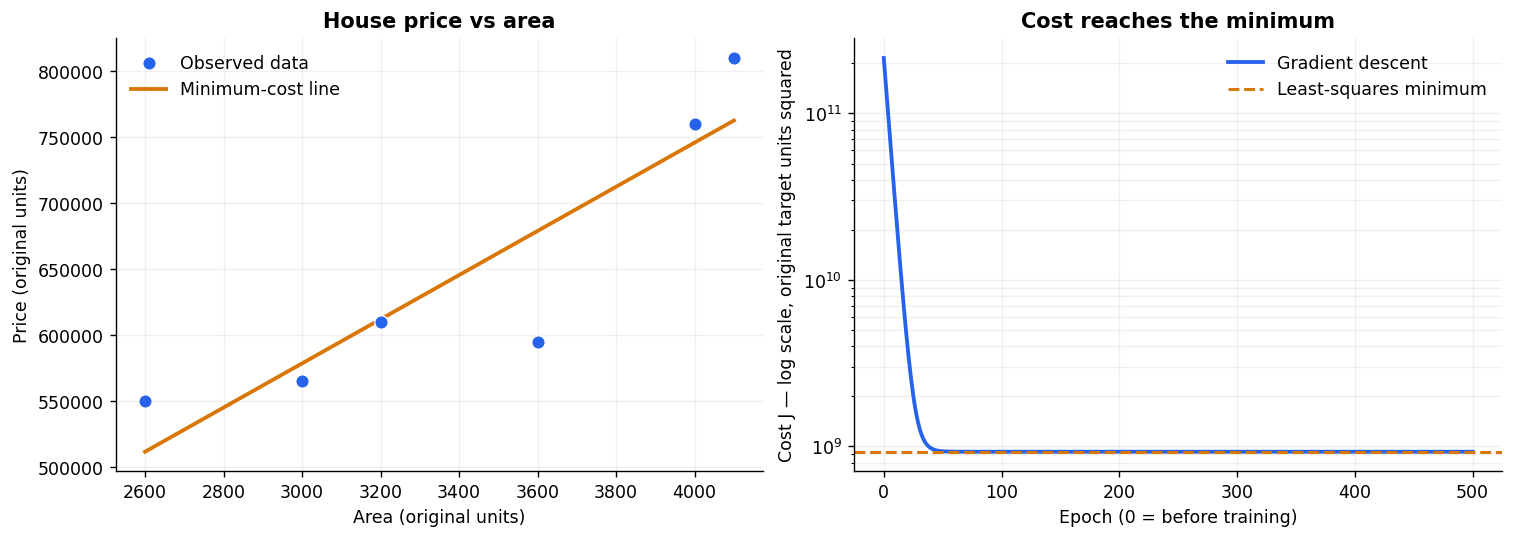

In [5]:
model = house_model
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), layout="constrained")

x_line = np.linspace(model["x"].min(), model["x"].max(), 150)
axes[0].scatter(model["x"], model["y"], s=60, color="#2563EB",
                edgecolors="white", linewidths=0.8, label="Observed data", zorder=3)
axes[0].plot(x_line, model["w"] * x_line + model["b"],
             color="#D97706", linewidth=2.2, label="Minimum-cost line")
axes[0].set(title='House price vs area', xlabel='Area (original units)', ylabel='Price (original units)')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.18)
axes[0].ticklabel_format(axis="both", style="plain", useOffset=False)

axes[1].semilogy(np.arange(len(model["history"])), model["history"],
                  color="#2563EB", linewidth=2.2, label="Gradient descent")
axes[1].axhline(model["minimum_cost"], color="#D97706", linestyle="--",
                linewidth=1.7, label="Least-squares minimum")
axes[1].set(title="Cost reaches the minimum", xlabel="Epoch (0 = before training)",
            ylabel="Cost J — log scale, original target units squared")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.18, which="both")
plt.show()

In [12]:
w


np.float64(1.4277564182066216)

In [13]:
b

np.float64(-41.96837405432217)

In [6]:
def predict_price(area_value):
    # These saved coefficients already use ordinary area units.
    return house_model["w"] * np.asarray(area_value, dtype=float) + house_model["b"]

new_area = 1500
print(f"Predicted price for area {new_area}: {float(predict_price(new_area)):,.2f}")
print("1500 is outside the training range 2600–4100; this is an extrapolation.")

Predicted price for area 1500: 327,656.70
1500 is outside the training range 2600–4100; this is an extrapolation.


## Task 2 — Predict exam score from attendance

The original eight student records are included below. Attendance is the
single input, as in the uploaded notebook; exam score is the target. The CSV
text is read directly, so the notebook works without a separate CSV file.
This also resolves the original filename mismatch.

In [7]:
student_csv = 'student_id,name,study_hours,attendance,assignment_score,exam_score\nSTU001,Ali,3,75,68,65\nSTU002,Sara,5,90,85,88\nSTU003,John,2,70,60,58\nSTU004,Ayesha,6,95,92,94\nSTU005,Bilal,4,80,75,73\nSTU006,Hina,7,98,90,96\nSTU007,Omar,1,65,55,50\nSTU008,Maryam,5,88,82,84\n'
df = pd.read_csv(StringIO(student_csv))
display(df)

x_original = df["attendance"].to_numpy(dtype=float)
y = df["exam_score"].to_numpy(dtype=float)
m = len(x_original)

x_mean = x_original.mean()
x_std = x_original.std()
x = (x_original - x_mean) / x_std

print(f"\nMean attendance: {x_mean:.6f}")
print(f"Attendance standard deviation: {x_std:.6f}")

,student_id,name,study_hours,attendance,assignment_score,exam_score
0,STU001,Ali,3,75,68,65
1,STU002,Sara,5,90,85,88
2,STU003,John,2,70,60,58
3,STU004,Ayesha,6,95,92,94
4,STU005,Bilal,4,80,75,73
5,STU006,Hina,7,98,90,96
6,STU007,Omar,1,65,55,50
7,STU008,Maryam,5,88,82,84



Mean attendance: 82.625000
Attendance standard deviation: 11.224276


In [8]:
# Fresh parameters for the standardized input.
w_scaled = 0.0
b_scaled = 0.0
alpha = 0.1
epochs = 500

cost_history = [float(np.mean((w_scaled * x + b_scaled - y) ** 2) / 2)]

for i in range(epochs):
    total_wxbyx = 0.0
    total_wxby = 0.0

    for j in range(m):
        error = w_scaled * x[j] + b_scaled - y[j]
        total_wxbyx += error * x[j]
        total_wxby += error

    # Both gradients use the same old parameters.
    temp_w = w_scaled - alpha * total_wxbyx / m
    temp_b = b_scaled - alpha * total_wxby / m
    w_scaled = temp_w
    b_scaled = temp_b

    # Report the cost AFTER this epoch's update.
    jwb = float(np.mean((w_scaled * x + b_scaled - y) ** 2) / 2)
    if not np.isfinite(jwb):
        raise FloatingPointError("Training diverged; check the input scaling.")
    cost_history.append(jwb)

    if i == 0 or (i + 1) % 100 == 0:
        print(f"Epoch {i + 1:3d} | Cost = {jwb:,.12f}")

# Convert the learned equation to ORIGINAL input units.
w = w_scaled / x_std
b = b_scaled - w * x_mean
x = x_original.copy()
u = w * x + b
jwb = float(np.mean((u - y) ** 2) / 2)

print(f"\nw = {w:.12f}")
print(f"b = {b:.12f}")
print(f"Final cost in original target units = {jwb:,.12f}")

Epoch   1 | Cost = 2,443.757319856133
Epoch 100 | Cost = 0.466159265642
Epoch 200 | Cost = 0.466157137542
Epoch 300 | Cost = 0.466157137542
Epoch 400 | Cost = 0.466157137542
Epoch 500 | Cost = 0.466157137542

w = 1.427756418207
b = -41.968374054322
Final cost in original target units = 0.466157137542


In [9]:
# Independent reference solution on the ORIGINAL input values.
design_matrix = np.column_stack((x, np.ones(m)))
reference_parameters, _, rank, _ = np.linalg.lstsq(design_matrix, y, rcond=None)
w_reference, b_reference = reference_parameters
reference_predictions = design_matrix @ reference_parameters
minimum_cost = float(np.mean((reference_predictions - y) ** 2) / 2)

np.testing.assert_allclose([w, b], reference_parameters, rtol=1e-10, atol=1e-7)
np.testing.assert_allclose(jwb, minimum_cost, rtol=1e-12, atol=1e-10)
assert rank == 2
assert np.isfinite(u).all()

errors = u - y
rmse = float(np.sqrt(np.mean(errors ** 2)))
mae = float(np.mean(np.abs(errors)))
r2 = float(1 - np.sum(errors ** 2) / np.sum((y - y.mean()) ** 2))

student_model = {
    "w": float(w), "b": float(b),
    "cost": jwb, "minimum_cost": minimum_cost,
    "rmse": rmse, "mae": mae, "r2": r2,
    "epochs": epochs, "history": np.array(cost_history),
    "x": x.copy(), "y": y.copy(),
}

print("PASS: gradient descent matches the least-squares minimum.")
print(f"Minimum cost J: {minimum_cost:,.12f}")
print(f"Absolute cost difference: {abs(jwb - minimum_cost):.3e}")
print(f"Training RMSE: {rmse:,.6f}")
print(f"Training MAE:  {mae:,.6f}")
print(f"Training R²:   {r2:.6f}")
display(pd.DataFrame({
    'Attendance': x,
    'Actual exam score': y,
    'Predicted exam score': u,
    "Error (prediction - actual)": errors,
}).round(4))

PASS: gradient descent matches the least-squares minimum.
Minimum cost J: 0.466157137542
Absolute cost difference: 2.776e-15
Training RMSE: 0.965564
Training MAE:  0.725226
Training R²:   0.996383


,Attendance,Actual exam score,Predicted exam score,Error (prediction - actual)
0,75.0,65.0,65.1134,0.1134
1,90.0,88.0,86.5297,-1.4703
2,70.0,58.0,57.9746,-0.0254
3,95.0,94.0,93.6685,-0.3315
4,80.0,73.0,72.2521,-0.7479
5,98.0,96.0,97.9518,1.9518
6,65.0,50.0,50.8358,0.8358
7,88.0,84.0,83.6742,-0.3258


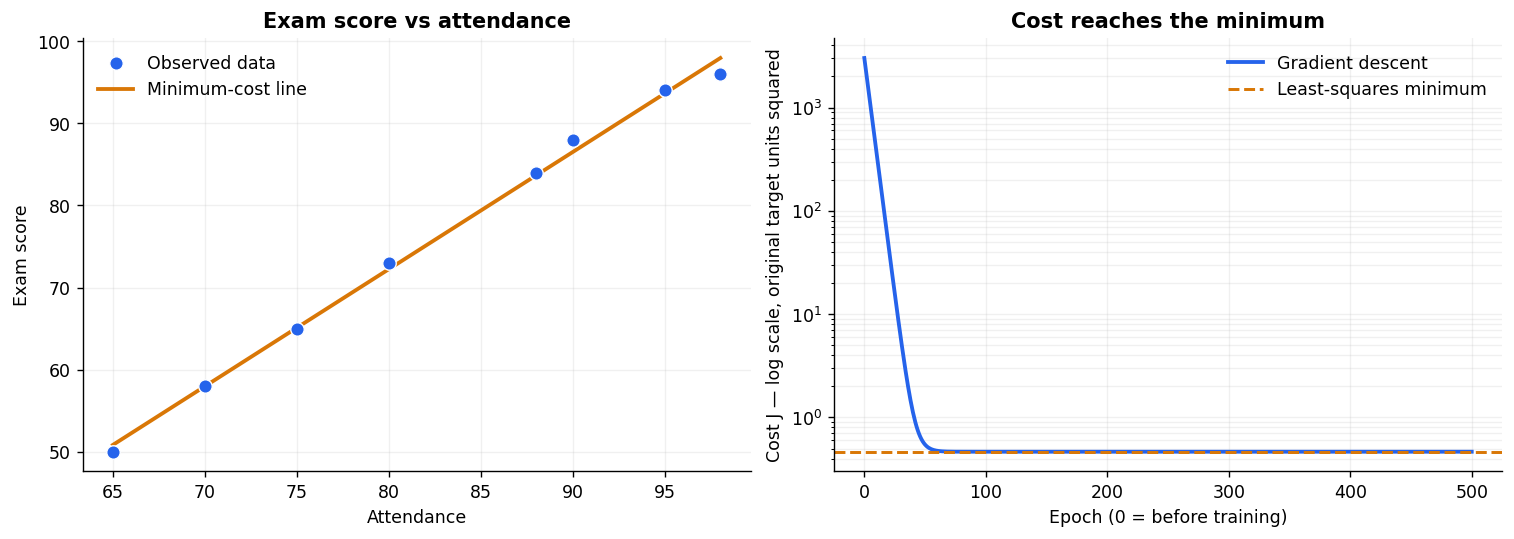

In [10]:
model = student_model
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), layout="constrained")

x_line = np.linspace(model["x"].min(), model["x"].max(), 150)
axes[0].scatter(model["x"], model["y"], s=60, color="#2563EB",
                edgecolors="white", linewidths=0.8, label="Observed data", zorder=3)
axes[0].plot(x_line, model["w"] * x_line + model["b"],
             color="#D97706", linewidth=2.2, label="Minimum-cost line")
axes[0].set(title='Exam score vs attendance', xlabel='Attendance', ylabel='Exam score')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.18)
axes[0].ticklabel_format(axis="both", style="plain", useOffset=False)

axes[1].semilogy(np.arange(len(model["history"])), model["history"],
                  color="#2563EB", linewidth=2.2, label="Gradient descent")
axes[1].axhline(model["minimum_cost"], color="#D97706", linestyle="--",
                linewidth=1.7, label="Least-squares minimum")
axes[1].set(title="Cost reaches the minimum", xlabel="Epoch (0 = before training)",
            ylabel="Cost J — log scale, original target units squared")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.18, which="both")
plt.show()

## Final results

Both tasks retain their original data and one-feature straight-line models.
The checks verify that gradient descent reaches the minimum squared-error
cost within floating-point tolerance. Costs below use **J = MSE / 2**.

In [11]:
summary = pd.DataFrame([
    {
        "Task": "1 — House price",
        "Epochs": house_model["epochs"],
        "Slope w": house_model["w"],
        "Intercept b": house_model["b"],
        "Final cost J": house_model["cost"],
        "Minimum cost J": house_model["minimum_cost"],
        "Training RMSE": house_model["rmse"],
        "Training R²": house_model["r2"],
    },
    {
        "Task": "2 — Student exam score",
        "Epochs": student_model["epochs"],
        "Slope w": student_model["w"],
        "Intercept b": student_model["b"],
        "Final cost J": student_model["cost"],
        "Minimum cost J": student_model["minimum_cost"],
        "Training RMSE": student_model["rmse"],
        "Training R²": student_model["r2"],
    },
])
with pd.option_context("display.float_format", "{:,.9f}".format):
    display(summary)

print("All checks passed. Both models reached their minimum linear-model cost.")

,Task,Epochs,Slope w,Intercept b,Final cost J,Minimum cost J,Training RMSE,Training R²
0,1 — House price,500,167.309546770,"76,692.381870781","929,415,782.706524491","929,415,782.706524849","43,114.168963498",0.812659753
1,2 — Student exam score,500,1.427756418,-41.968374054,0.466157138,0.466157138,0.965564226,0.996382874


All checks passed. Both models reached their minimum linear-model cost.


**How to read these results**

- Standardizing the input speeds up convergence; the minimum is measured on
  the original target scale.
- House-price cost is numerically much larger than exam-score cost because
  the targets have different scales and errors are squared. Compare RMSE
  with the target's units to interpret the error.
- The remaining error cannot be removed by adding more epochs to these
  same straight-line models.
- All reported metrics are training metrics. These very small datasets do
  not establish how well the models will predict new observations.